In [23]:
import os
import sys
import shutil
import math
import warnings
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import *
from enum import Enum
from scipy.spatial import Voronoi
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import LabelEncoder
from scipy.stats import wasserstein_distance
sys.path.append("/home/esraan/CellDeathSpreading/")
from src.utils import get_experiment_cell_death_times_by_specific_siliding_window,read_experiment_cell_xy_and_death_times
from src.quanta_utils import get_neighbors
from src.DeathQuanta import DeathQuanta

In [15]:
all(meta_data_extract_exp_names[meta_data_extract_exp_names['File Name'] == exp_names[idx]]["DeathMode"] == 'pure')

False

In [28]:
meta_data_extract_exp_names[meta_data_extract_exp_names['File Name'] == exp_names[idx]]["Origin"].values[0]

'pure_colony_3'

In [6]:
exps_dir_name = "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/csv_files_minutes_microns_live_only/" #mixed_pure_death_minutes_microns"
meta_data_file_full_path= "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/csv_files_minutes_microns_live_only.csv" # all_csv_files_minutes_microns_with_sytox.csv"
meta_data_extract_exp_names= pd.read_csv(meta_data_file_full_path)
exp_names = meta_data_extract_exp_names.iloc[:,1]
group_data = {}
for idx in range(len(exp_names)):
    # if not all(meta_data_extract_exp_names[meta_data_extract_exp_names['File Name'] == exp_names[idx]]["DeathMode"] == 'pure'):
    #     continue
    if 'pure' not in exp_names[idx].lower():# or 'zvad_fullmedia_puredeath3_sytox_based' in exp_names[idx]:
        continue
    print(exp_names[idx])
    exp_full_path = os.path.join(exps_dir_name, exp_names[idx])
    csv_file = pd.read_csv(exp_full_path)
    dist_threshold = 50 # microns
    cells_location = csv_file[["cell_x","cell_y"]].values
    di_times = csv_file[['death_time']].values
    death_modes = csv_file[["Mode"]].values if "Mode" in csv_file.columns else []
    de_qu = DeathQuanta(cells_xy=cells_location,
                        death_times=di_times, 
                        death_modes=death_modes,
                        dist_threshold=dist_threshold,
                        filter_neighbors_by_distance=True,
                        neighbors_level=1,
                        pure_type = meta_data_extract_exp_names[meta_data_extract_exp_names['File Name']==exp_names[idx]]["Mode"].values[0])
    tod_pairs_1 = de_qu.get_org_deltaTOD_neighbors_pairs()
    group_data[meta_data_extract_exp_names[meta_data_extract_exp_names['File Name'] == exp_names[idx]]["Origin"].values[0]] = tod_pairs_1

purecolony3.csv
purecolony1.csv
Purecolony2.csv


In [24]:
exps_dir_name = "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/"
meta_data_file_full_path= "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/all_csv_files_minutes_microns_with_sytox.csv"
meta_data_extract_exp_names= pd.read_csv(meta_data_file_full_path)
exp_names = meta_data_extract_exp_names.iloc[:,1]
group_data = {}
for idx in range(len(exp_names)):
    # if not all(meta_data_extract_exp_names[meta_data_extract_exp_names['File Name'] == exp_names[idx]]["DeathMode"] == 'Apoptosis'):
    #     continue
    if 'nec' in exp_names[idx] or 'apop' in exp_names[idx] or 'out' in exp_names[idx] or 'skt' in exp_names[idx].lower():# or 'zvad_fullmedia_puredeath3_sytox_based' in exp_names[idx]:
        continue
    # if 'pure' not in exp_names[idx]:# or 'zvad_fullmedia_puredeath3_sytox_based' in exp_names[idx]:
    #     continue
    print(exp_names[idx])
    exp_full_path = os.path.join(exps_dir_name, exp_names[idx])
    csv_file = pd.read_csv(exp_full_path)
    dist_threshold = 100 # microns
    cells_location = csv_file[["cell_x","cell_y"]].values
    di_times = csv_file[['death_time']].values
    death_modes = csv_file[["Mode"]].values if "Mode" in csv_file.columns else []
    de_qu = DeathQuanta(cells_xy=cells_location,
                        death_times=di_times, 
                        death_modes=death_modes,
                        dist_threshold=dist_threshold,
                        filter_neighbors_by_distance=True,
                        neighbors_level=1,
                        pure_type = meta_data_extract_exp_names[meta_data_extract_exp_names['File Name']==exp_names[idx]]["Mode"].values[0])
    tod_pairs_1 = de_qu.get_org_deltaTOD_neighbors_pairs()
    group_data[meta_data_extract_exp_names[meta_data_extract_exp_names['File Name'] == exp_names[idx]]["Origin"].values[0]] = tod_pairs_1 # tod_pairs_1.get('apoptosis', []) + tod_pairs_1.get('necrosis', []) if isinstance(tod_pairs_1, dict) else tod_pairs_1

field13_crop-001_ROI#1_annotation_mixed.csv
Field14-002_ROI#1_annotation_mixed.csv
7-20-23_10arednuclei_ROI#10_annotation_mixed.csv
7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_mixed.csv
purecolony3_sytox_based.csv
purecolony_sytox_based.csv
purecolony2_sytox_based.csv
mixcolony1.csv
mixcolony2_field13.csv
mixcolony3.csv
3-11-23_10ah2bmch_ml+zvad_fullmedia_puredeath1_sytox_based.csv
3-11-23_10ah2bmch_ml+zvad_fullmedia_puredeath2_sytox_based.csv
3-11-23_10ah2bmch_ml+zvad_fullmedia_puredeath3_sytox_based.csv


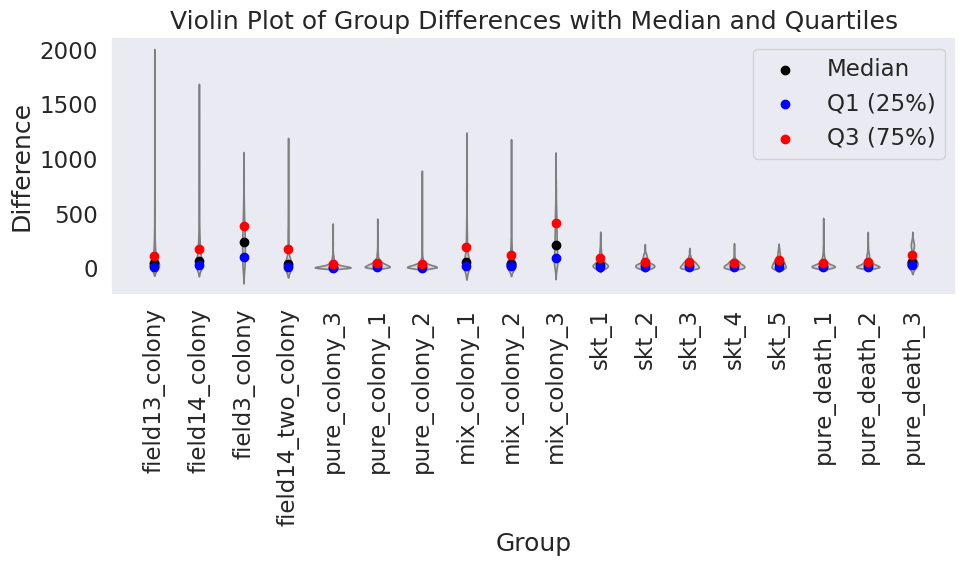

In [17]:
# Flatten into a DataFrame
flattened_data = {
    'Group': [],
    'Difference': []
}

for group_name, arrays in group_data.items():
    for arr in arrays:
        flattened_data['Group'].extend([group_name] * len(arr))
        flattened_data['Difference'].extend(arr)

df = pd.DataFrame(flattened_data)

# Plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='Group', y='Difference', data=df, inner=None, linewidth=1.2, color='lightgray')

# Add median, Q1, Q3 points and text annotations
for i, group in enumerate(df['Group'].unique()):
    group_values = df[df['Group'] == group]['Difference']
    median = np.median(group_values)
    q1 = np.percentile(group_values, 25)
    q3 = np.percentile(group_values, 75)
    
    plt.scatter(i, median, color='black', label='Median' if i == 0 else "", zorder=3)
    plt.scatter(i, q1, color='blue', marker='o', label='Q1 (25%)' if i == 0 else "", zorder=3)
    plt.scatter(i, q3, color='red', marker='o', label='Q3 (75%)' if i == 0 else "", zorder=3)
    
    # Add text annotations
    # plt.text(i + 0.1, median, f'{median:.2f}', va='center', ha='left', fontsize=9, color='black')
    # plt.text(i + 0.1, q1, f'{q1:.2f}', va='center', ha='left', fontsize=9, color='blue')
    # plt.text(i + 0.1, q3, f'{q3:.2f}', va='center', ha='left', fontsize=9, color='red')

plt.title('Violin Plot of Group Differences with Median and Quartiles')
plt.ylabel('Difference')
plt.xticks(rotation=90)
plt.grid(False)#, axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_3150572/1883716783.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Difference', data=df, width=0.5, palette='pastel', showfliers=False)


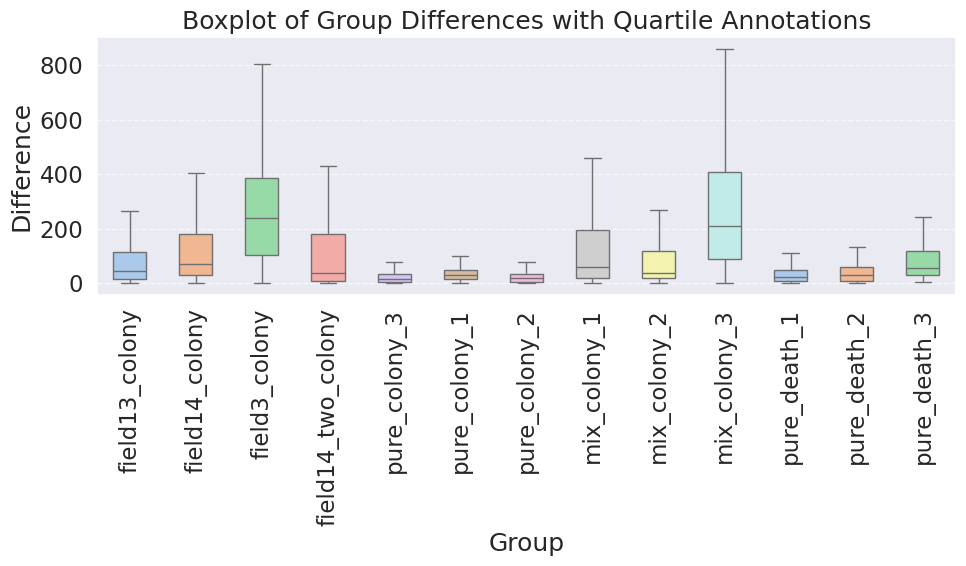

In [23]:
# Flatten into DataFrame
flattened_data = {'Group': [], 'Difference': []}
for group_name, arrays in group_data.items():
    for arr in arrays:
        flattened_data['Group'].extend([group_name] * len(arr))
        flattened_data['Difference'].extend(arr)

df = pd.DataFrame(flattened_data)

# Plot boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Group', y='Difference', data=df, width=0.5, palette='pastel', showfliers=False)

# Annotate median, Q1, Q3
for i, group in enumerate(df['Group'].unique()):
    group_values = df[df['Group'] == group]['Difference']
    median = np.median(group_values)
    q1 = np.percentile(group_values, 25)
    q3 = np.percentile(group_values, 75)

    # plt.text(i, median, f'{median:.2f}', va='center', ha='right', fontsize=9, color='black')
    # plt.text(i, q1, f'{q1:.2f}', va='center', ha='right', fontsize=9, color='blue')
    # plt.text(i, q3, f'{q3:.2f}', va='center', ha='right', fontsize=9, color='red')

# Customize axis and layout
plt.xticks(rotation=90)
plt.title('Boxplot of Group Differences with Quartile Annotations')
plt.ylabel('Difference')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1284629/672842238.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='GroupLabel', y='Difference', data=df,


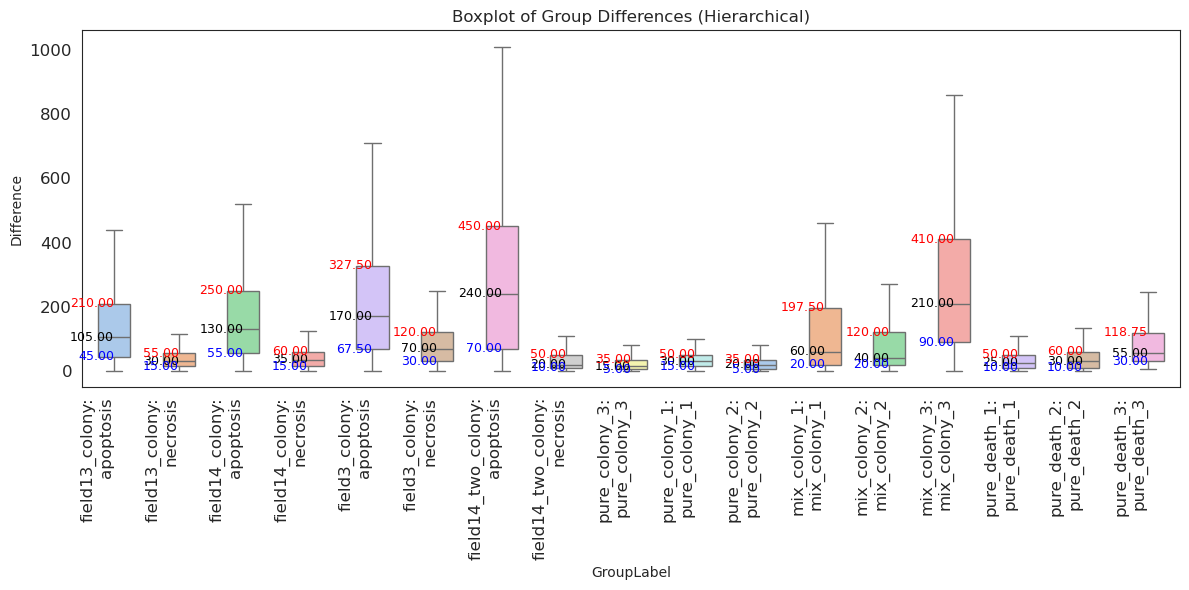

In [3]:
flattened_data = {'Group': [], 'Difference': []}
# Remove "entosis" from group_data
filtered_group_data = {}
for group_name, subgroups in group_data.items():
    if isinstance(subgroups, dict):  # Check if subgroups exist
        filtered_subgroups = {subgroup_name: arrays for subgroup_name, arrays in subgroups.items() if subgroup_name != "entosis"}
        if filtered_subgroups:  # Add only if there are remaining subgroups
            filtered_group_data[group_name] = filtered_subgroups
    else:
        filtered_group_data[group_name] = subgroups  # Keep flat structure unchanged

group_data = filtered_group_data

for group_name, value in group_data.items():
    if isinstance(value, dict):  # Nested: group → subgroup → arrays
        for subgroup_name, arrays in value.items():
            label = f"{group_name}/{subgroup_name}"
            for arr in arrays:
                flattened_data['Group'].extend([label] * len(arr))
                flattened_data['Difference'].extend(arr)
    else:  # Flat list of arrays
        for arr in value:
            flattened_data['Group'].extend([group_name] * len(arr))
            flattened_data['Difference'].extend(arr)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.DataFrame(flattened_data)

# Sort groups hierarchically
df['MainGroup'] = df['Group'].apply(lambda x: x.split('/')[0])
df['SubGroup'] = df['Group'].apply(lambda x: x.split('/')[1] if '/' in x else x)
df['GroupLabel'] = df['MainGroup'] + ':\n' + df['SubGroup']  # for axis formatting

# Plot boxplot
plt.figure(figsize=(12, 6))
sns.set_style("white") 
sns.boxplot(x='GroupLabel', y='Difference', data=df,
            width=0.5, palette='pastel', showfliers=False)

# Annotate quartiles
for i, label in enumerate(df['GroupLabel'].unique()):
    values = df[df['GroupLabel'] == label]['Difference']
    median = np.median(values)
    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)

    # Annotate: uncomment if needed
    plt.text(i, median, f'{median:.2f}', va='center', ha='right', fontsize=9, color='black')
    plt.text(i, q1, f'{q1:.2f}', va='center', ha='right', fontsize=9, color='blue')
    plt.text(i, q3, f'{q3:.2f}', va='center', ha='right', fontsize=9, color='red')
plt.xticks(fontsize=12, rotation=90, ha='right',ticks=range(len(df['GroupLabel'].unique())))
plt.yticks(fontsize=12)
# Format plot
# plt.xticks(rotation=90, ha='right')
plt.title('Boxplot of Group Differences (Hierarchical)')
plt.ylabel('Difference')
plt.grid(False)#, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("/home/esraan/CellDeathSpreading/results/boxplot_hierarchical.svg", format="svg", dpi=300)
plt.show()
# Save the plot as a high-resolution image suitable for Adobe Illustrator



/tmp/ipykernel_1284629/341724298.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='GroupLabel', y='Difference', data=df, width=0.5, palette='pastel', showfliers=False)


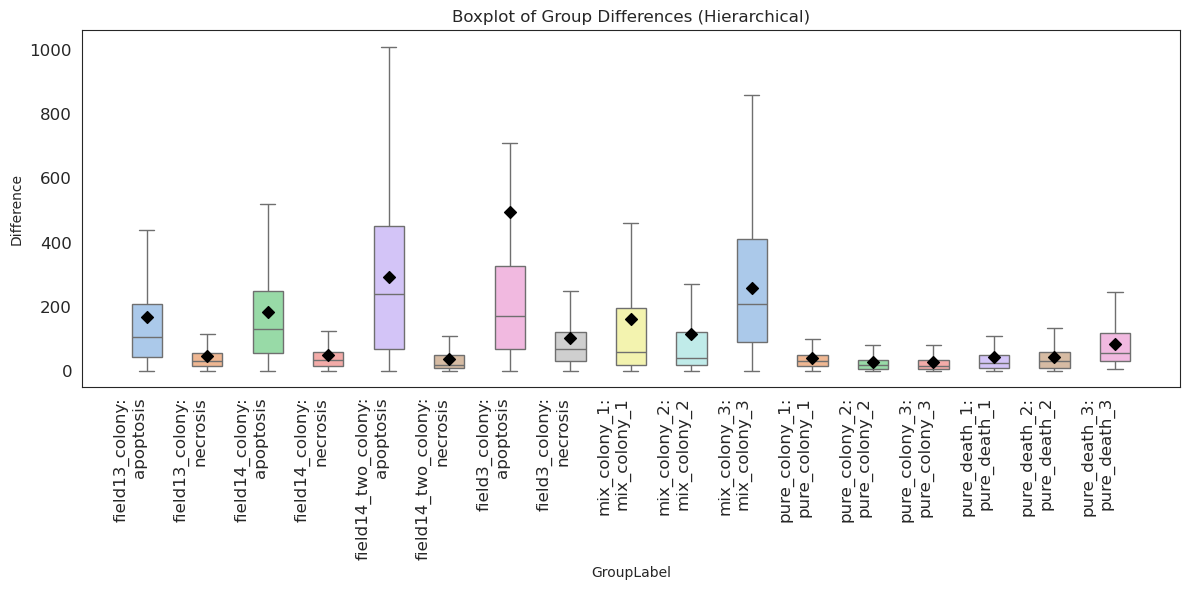

In [29]:
# Add a temporary column for sorting
df['SortOrder'] = df['MainGroup'].apply(lambda x: 1 if 'pure' in x.lower() else 0)

# Sort the DataFrame by the temporary column and GroupLabel
df = df.sort_values(by=['SortOrder', 'GroupLabel'], ascending=[True, True])

# Drop the temporary column used for sorting
df = df.drop(columns=['SortOrder'])

# Plot boxplot
plt.figure(figsize=(12, 6))
sns.set_style("white")
sns.boxplot(x='GroupLabel', y='Difference', data=df, width=0.5, palette='pastel', showfliers=False)

# Annotate quartiles
for i, label in enumerate(df['GroupLabel'].unique()):
    values = df[df['GroupLabel'] == label]['Difference']
    median = np.median(values)
    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)
    mean = np.mean(values)
    plt.scatter(i, mean, color='black', marker='D', label='Mean' if i == 0 else "", zorder=3)

    # Annotate: uncomment if needed
    # plt.text(i, median, f'{median:.2f}', va='center', ha='right', fontsize=9, color='black')
    # plt.text(i, q1, f'{q1:.2f}', va='center', ha='right', fontsize=9, color='blue')
    # plt.text(i, q3, f'{q3:.2f}', va='center', ha='right', fontsize=9, color='red')

plt.xticks(fontsize=12, rotation=90, ha='right', ticks=range(len(df['GroupLabel'].unique())))
plt.yticks(fontsize=12)

# Format plot
plt.title('Boxplot of Group Differences (Hierarchical)')
plt.ylabel('Difference')
plt.grid(False)
plt.tight_layout()
plt.savefig("/home/esraan/CellDeathSpreading/results/boxplot_hierarchical_sorted.svg", format="svg", dpi=300)
plt.show()


/tmp/ipykernel_1284629/421356680.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='GroupLabel', y='Difference', data=filtered_df, width=0.5, palette='pastel', showfliers=False)


<Figure size 1200x600 with 0 Axes>

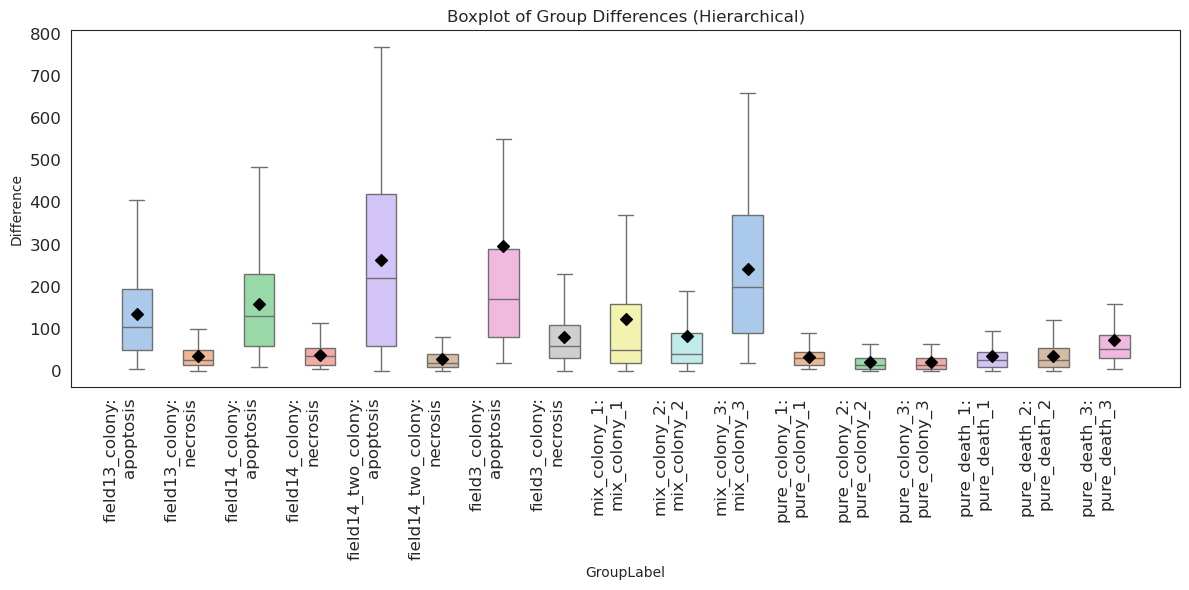

In [28]:
# Add a temporary column for sorting
df['SortOrder'] = df['MainGroup'].apply(lambda x: 1 if 'pure' in x.lower() else 0)

# Sort the DataFrame by the temporary column and GroupLabel
df = df.sort_values(by=['SortOrder', 'GroupLabel'], ascending=[True, True])

# Drop the temporary column used for sorting
df = df.drop(columns=['SortOrder'])

# Plot boxplot
plt.figure(figsize=(12, 6))
sns.set_style("white")

# Remove outliers for each group and subgroup
filtered_df = pd.DataFrame(columns=df.columns)
for group_label in df['GroupLabel'].unique():
    group_values = df[df['GroupLabel'] == group_label]['Difference']
    lower_bound = np.percentile(group_values, 5)
    upper_bound = np.percentile(group_values, 95)
    filtered_group = df[(df['GroupLabel'] == group_label) & (df['Difference'] >= lower_bound) & (df['Difference'] <= upper_bound)]
    filtered_df = pd.concat([filtered_df, filtered_group])

# Plot boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='GroupLabel', y='Difference', data=filtered_df, width=0.5, palette='pastel', showfliers=False)

# Annotate mean
for i, label in enumerate(filtered_df['GroupLabel'].unique()):
    values = filtered_df[filtered_df['GroupLabel'] == label]['Difference']
    mean = np.mean(values)
    plt.scatter(i, mean, color='black', marker='D', label='Mean' if i == 0 else "", zorder=3)
    # plt.text(i, mean, f'{mean:.2f}', va='center', ha='right', fontsize=9, color='green')

plt.xticks(fontsize=12, rotation=90, ha='right', ticks=range(len(filtered_df['GroupLabel'].unique())))
plt.yticks(fontsize=12)
# sns.boxplot(x='GroupLabel', y='Difference', data=df, width=0.5, palette='pastel', showfliers=False)

# Annotate quartiles
for i, label in enumerate(df['GroupLabel'].unique()):
    values = df[df['GroupLabel'] == label]['Difference']
    median = np.median(values)
    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)

    # Annotate: uncomment if needed
    # plt.text(i, median, f'{median:.2f}', va='center', ha='right', fontsize=9, color='black')
    # plt.text(i, q1, f'{q1:.2f}', va='center', ha='right', fontsize=9, color='blue')
    # plt.text(i, q3, f'{q3:.2f}', va='center', ha='right', fontsize=9, color='red')

plt.xticks(fontsize=12, rotation=90, ha='right', ticks=range(len(df['GroupLabel'].unique())))
plt.yticks(fontsize=12)

# Format plot
plt.title('Boxplot of Group Differences (Hierarchical)')
plt.ylabel('Difference')
plt.grid(False)
plt.tight_layout()
plt.savefig("/home/esraan/CellDeathSpreading/results/boxplot_new_hierarchical_sorted_no_out.svg", format="svg", dpi=300)
plt.show()


In [20]:
from scipy.stats import kruskal
subgroups = [df[df['SubGroup'] == subgroup]['Difference'] for subgroup in df['SubGroup'].unique()]
# Example
kruskal(*subgroups)
from scipy.stats import median_test

# Example
stat, p, med, tbl = median_test(*subgroups)
print(f"Median Test Statistic: {stat}, p-value: {p}, Median: {med}")
print(f"Contingency Table:\n{tbl}")

Median Test Statistic: 5408.615903686629, p-value: 0.0, Median: 30.0
Contingency Table:
[[3532 2304 1230 1790  998 2428 1712 1176 1998 1698   80]
 [ 730 2714  680 1298  126 3132 4656 3440 2902 2116   30]]


In [22]:
import scikit_posthocs as sp

sp.posthoc_dunn(subgroups, p_adjust='bonferroni')


,1,2,3,4,5,6,7,8,9,10,11
1,1.000000e+00,0.000000e+00,8.235648e-56,7.482575e-143,1.399107e-11,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.012846e-03
2,0.000000e+00,1.000000e+00,9.369485e-77,4.203709e-48,5.562384e-283,1.701179e-02,9.686407e-106,3.752378e-123,1.448919e-04,1.000000e+00,1.989219e-06
3,8.235648e-56,9.369485e-77,1.000000e+00,8.281688e-07,1.417391e-72,2.551540e-102,1.126056e-270,1.264425e-287,2.242266e-107,6.095399e-83,1.000000e+00
4,7.482575e-143,4.203709e-48,8.281688e-07,1.000000e+00,6.979934e-130,1.001528e-72,3.625989e-258,1.315366e-273,8.796292e-78,2.668981e-54,1.000000e+00
5,1.399107e-11,5.562384e-283,1.417391e-72,6.979934e-130,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.995829e-287,2.322790e-09
6,0.000000e+00,1.701179e-02,2.551540e-102,1.001528e-72,0.000000e+00,1.000000e+00,2.771169e-77,1.641342e-94,1.000000e+00,1.000000e+00,2.347473e-08
7,0.000000e+00,9.686407e-106,1.126056e-270,3.625989e-258,0.000000e+00,2.771169e-77,1.000000e+00,1.941321e-02,2.058487e-62,1.453807e-72,4.005137e-21
8,0.000000e+00,3.752378e-123,1.264425e-287,1.315366e-273,0.000000e+00,1.641342e-94,1.941321e-02,1.000000e+00,4.855663e-79,3.573072e-89,3.520646e-24
9,0.000000e+00,1.448919e-04,2.242266e-107,8.796292e-78,0.000000e+00,1.000000e+00,2.058487e-62,4.855663e-79,1.000000e+00,8.776998e-01,4.856204e-09
10,0.000000e+00,1.000000e+00,6.095399e-83,2.668981e-54,6.995829e-287,1.000000e+00,1.453807e-72,3.573072e-89,8.776998e-01,1.000000e+00,1.691713e-07


F-statistic: 1145.0526817526322
P-value: 0.0
          Multiple Comparison of Means - Tukey HSD, FWER=0.00          
    group1        group2     meandiff p-adj    lower     upper   reject
-----------------------------------------------------------------------
    apoptosis  mix_colony_1  -61.0127    0.0  -76.1853  -45.8401   True
    apoptosis  mix_colony_2 -106.4672    0.0 -119.4889  -93.4454   True
    apoptosis  mix_colony_3   37.2579    0.0   18.7817   55.7341   True
    apoptosis      necrosis -170.8329    0.0 -182.3111 -159.3548   True
    apoptosis pure_colony_1 -182.6521    0.0 -193.8704 -171.4339   True
    apoptosis pure_colony_2 -192.5842    0.0 -203.4893 -181.6792   True
    apoptosis pure_colony_3 -194.1243    0.0 -205.8298 -182.4189   True
    apoptosis  pure_death_1 -176.9191    0.0 -188.4606 -165.3777   True
    apoptosis  pure_death_2 -177.6738    0.0 -189.9559 -165.3918   True
    apoptosis  pure_death_3 -137.7457    0.0 -190.9573   -84.534   True
 mix_colony_1  mix_

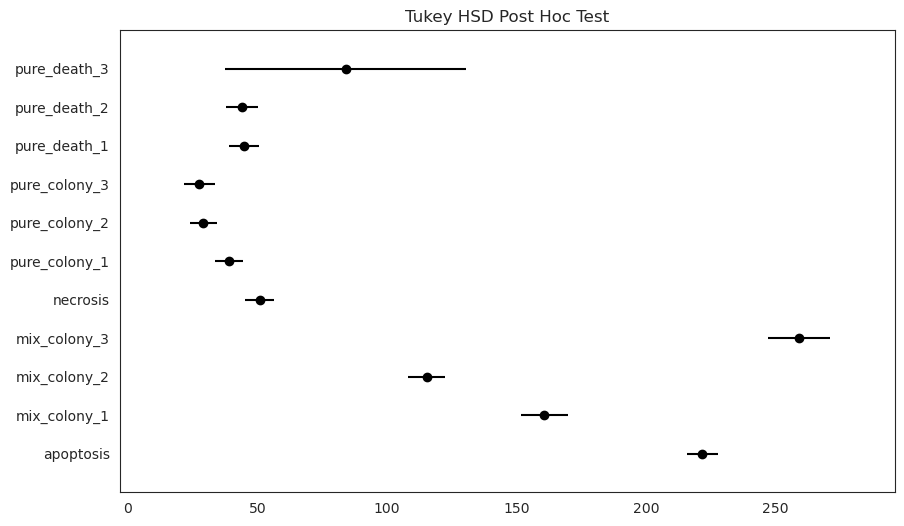

In [17]:
from scipy.stats import f_oneway

# Extract subgroups
subgroups = [df[df['SubGroup'] == subgroup]['Difference'] for subgroup in df['SubGroup'].unique()]

# Perform one-way ANOVA
F, p = f_oneway(*subgroups)

print(f"F-statistic: {F}")
print(f"P-value: {p}")
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# tukey = pairwise_tukeyhsd(endog=df['value'], groups=df['group'], alpha=0.05)
# print(tukey)
# Perform Tukey's HSD post hoc test

tukey = pairwise_tukeyhsd(endog=df['Difference'], groups=df['SubGroup'], alpha=0.001)

# Print the results
print(tukey)

# Plot the results
tukey.plot_simultaneous()
plt.title('Tukey HSD Post Hoc Test')
plt.show()

In [ ]:
# Filter groups with "pure" in their name
pure_groups = [group for group in group_data.keys() if "pure" in group.lower()]

# Flatten data for pure groups
pure_flattened_data = {'Group': [], 'Difference': []}
for group_name in pure_groups:
    for arr in group_data[group_name]:
        pure_flattened_data['Group'].extend([group_name] * len(arr))
        pure_flattened_data['Difference'].extend(arr)

# Create a DataFrame for pure groups
pure_df = pd.DataFrame(pure_flattened_data)

# Plot violin plot for pure groups
plt.figure(figsize=(10, 6))
sns.violinplot(x='Group', y='Difference', data=pure_df, inner=None, linewidth=1.2, color='lightgray')

# Customize plot
plt.title('Violin Plot of Differences for Pure Groups')
plt.ylabel('Difference')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

,Group,Difference,MainGroup,SubGroup,GroupLabel
0,field13_colony/apoptosis,5,field13_colony,apoptosis,field13_colony:\napoptosis
1,field13_colony/apoptosis,125,field13_colony,apoptosis,field13_colony:\napoptosis
2,field13_colony/apoptosis,5,field13_colony,apoptosis,field13_colony:\napoptosis
3,field13_colony/apoptosis,125,field13_colony,apoptosis,field13_colony:\napoptosis
4,field13_colony/apoptosis,395,field13_colony,apoptosis,field13_colony:\napoptosis
...,...,...,...,...,...
40765,pure_death_3,55,pure_death_3,pure_death_3,pure_death_3:\npure_death_3
40766,pure_death_3,120,pure_death_3,pure_death_3,pure_death_3:\npure_death_3
40767,pure_death_3,160,pure_death_3,pure_death_3,pure_death_3:\npure_death_3
40768,pure_death_3,85,pure_death_3,pure_death_3,pure_death_3:\npure_death_3


In [7]:
group_names = list(group_data.keys())
n = len(group_names)

# Create a distance matrix
distance_matrix = np.zeros((n, n))

# Fill in distances
for i in range(n):
    for j in range(n):
        distance_matrix[i, j] = wasserstein_distance(np.concatenate(group_data[group_names[i]]),
                                                     np.concatenate(group_data[group_names[j]]))

# Convert to DataFrame for easier viewing
distance_df = pd.DataFrame(distance_matrix, index=group_names, columns=group_names)

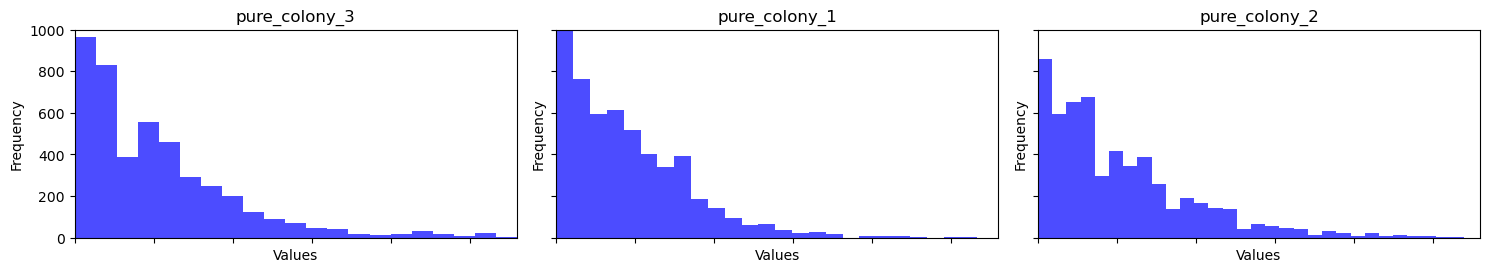

In [8]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, group_name in enumerate(group_names):
    data = np.concatenate(group_data[group_name])
    axes[i].hist(data, bins=30, alpha=0.7, color='blue')
    axes[i].set_title(group_name)
    axes[i].set_xlabel('Values')
    axes[i].set_ylabel('Frequency')
    axes[i].set_xlim(0, max(data) + 10)  # Adjust x-axis limits
    axes[i].set_ylim(0, 1000)  # Adjust y-axis limits (example value)

# Remove unused subplots
for j in range(len(group_names), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [37]:
distance_df = distance_df.drop(index='pure_death_3', columns='pure_death_3')
distance_df

,pure_colony_3,pure_colony_1,pure_colony_2,skt_1,skt_2,skt_3,skt_4,skt_5,pure_death_1,pure_death_2
pure_colony_3,0.000000,13.058435,4.622838,11.368805,13.101389,12.232782,12.462004,8.685142,18.628670,18.233915
pure_colony_1,13.058435,0.000000,13.415586,12.309690,12.764213,11.165725,9.659257,14.207119,8.135975,6.028155
pure_colony_2,4.622838,13.415586,0.000000,13.472844,12.991410,14.403085,12.554702,11.104430,18.682732,18.627750
skt_1,11.368805,12.309690,13.472844,0.000000,13.056478,8.317587,12.346346,7.534884,11.803027,13.144590
skt_2,13.101389,12.764213,12.991410,13.056478,0.000000,16.941964,15.535714,11.571429,17.241543,16.117255
skt_3,12.232782,11.165725,14.403085,8.317587,16.941964,0.000000,9.575893,7.468750,13.901828,12.564124
skt_4,12.462004,9.659257,12.554702,12.346346,15.535714,9.575893,0.000000,10.392857,15.813641,13.748106
skt_5,8.685142,14.207119,11.104430,7.534884,11.571429,7.468750,10.392857,0.000000,19.016646,17.980559
pure_death_1,18.628670,8.135975,18.682732,11.803027,17.241543,13.901828,15.813641,19.016646,0.000000,5.523188
pure_death_2,18.233915,6.028155,18.627750,13.144590,16.117255,12.564124,13.748106,17.980559,5.523188,0.000000


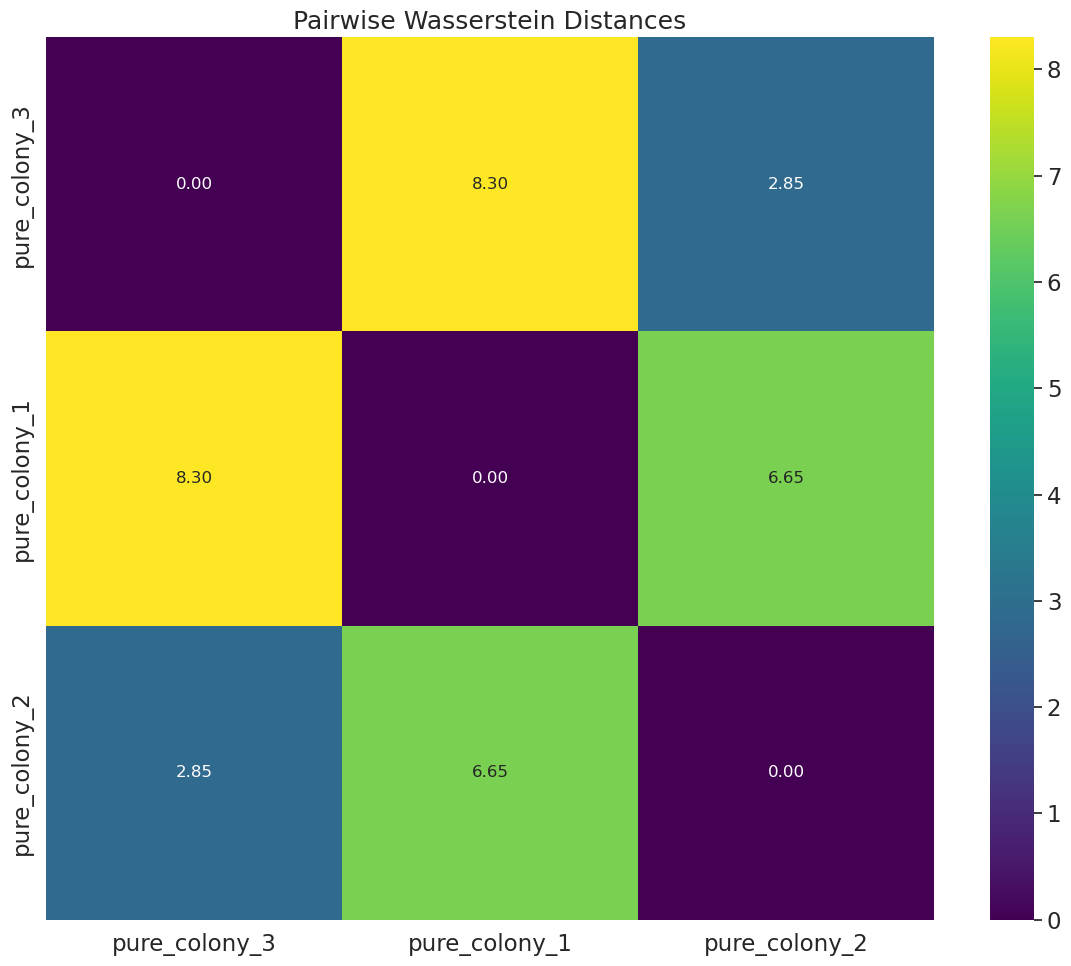

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# plt.figure(figsize=(6, 5))
# sns.heatmap(distance_df, annot=True, fmt=".2f", cmap="viridis")
# plt.title("Pairwise Wasserstein Distances")
# plt.tight_layout()
# plt.show()

sns.set(font_scale=1.5)  # Increase font size
plt.figure(figsize=(12, 10))  # Make the figure larger
sns.heatmap(distance_df, annot=True, fmt=".2f", cmap="viridis", annot_kws={"size": 12})  # Adjust annotation font size
plt.title("Pairwise Wasserstein Distances", fontsize=18)  # Enhance title font size
plt.tight_layout()
plt.show()


In [16]:
import random

def permute_test(group1, group2, num_permutations=1000):
    combined = np.concatenate([group1, group2])
    actual_distance = wasserstein_distance(group1, group2)
    permuted_distances = []

    for _ in range(num_permutations):
        np.random.shuffle(combined)
        perm_group1 = combined[:len(group1)]
        perm_group2 = combined[len(group1):]
        permuted_distances.append(wasserstein_distance(perm_group1, perm_group2))

    p_value = np.mean(np.array(permuted_distances) >= actual_distance)
    return actual_distance, p_value
results = {}

for group1_name, group1_data in group_data.items():
    for group2_name, group2_data in group_data.items():
        if group1_name != group2_name:  # Avoid comparing the same group
            actual_distance, p_value = permute_test(np.concatenate(group1_data), np.concatenate(group2_data))
            results[(group1_name, group2_name)] = {'distance': actual_distance, 'p_value': p_value}

# Display the results
for pair, result in results.items():
    print(f"Comparison: {pair[0]} vs {pair[1]}")
    print(f"Distance: {result['distance']:.4f}, P-value: {result['p_value']:.4f}")
    print()


Comparison: purecolony3_sytox_based.csv vs purecolony_sytox_based.csv
Distance: 13.0584, P-value: 0.0000

Comparison: purecolony3_sytox_based.csv vs purecolony2_sytox_based.csv
Distance: 4.6228, P-value: 0.0000

Comparison: purecolony3_sytox_based.csv vs 3-11-23_10ah2bmch_ml+zvad_fullmedia_puredeath1_sytox_based.csv
Distance: 18.6287, P-value: 0.0000

Comparison: purecolony3_sytox_based.csv vs 3-11-23_10ah2bmch_ml+zvad_fullmedia_puredeath2_sytox_based.csv
Distance: 18.2339, P-value: 0.0000

Comparison: purecolony3_sytox_based.csv vs 3-11-23_10ah2bmch_ml+zvad_fullmedia_puredeath3_sytox_based.csv
Distance: 47.5308, P-value: 0.0000

Comparison: purecolony_sytox_based.csv vs purecolony3_sytox_based.csv
Distance: 13.0584, P-value: 0.0000

Comparison: purecolony_sytox_based.csv vs purecolony2_sytox_based.csv
Distance: 13.4156, P-value: 0.0000

Comparison: purecolony_sytox_based.csv vs 3-11-23_10ah2bmch_ml+zvad_fullmedia_puredeath1_sytox_based.csv
Distance: 8.1360, P-value: 0.0000

Comparison

In [8]:
np.concatenate(tod_pairs_1.get('apoptosis'))

array([18, 21,  7, ..., 17, 34, 24])

In [12]:
emd = wasserstein_distance(np.concatenate(tod_pairs_1.get('apoptosis')), np.concatenate(tod_pairs_2.get('apoptosis')))

In [13]:
emd

np.float64(4.04909758452148)

In [11]:
exps_dir_name = "/sise/assafzar-group/assafzar/Esraa/Others/fully_annotated_data/TimeFrames/"
meta_data_file_full_path= "/sise/assafzar-group/assafzar/Esraa/Others/ManuallyAnnotatedRoisuu.csv"
meta_data_extract_exp_names= pd.read_csv(meta_data_file_full_path)
exp_names = meta_data_extract_exp_names.iloc[:,1]
print(exp_names[1])
exp_full_path = os.path.join(exps_dir_name, exp_names[1])
csv_file = pd.read_csv(exp_full_path)
dist_threshold = 100
cells_location = csv_file[["cell_x","cell_y"]].values
di_times = csv_file[['death_time']].values
death_modes = csv_file[["Mode"]].values
de_qu = DeathQuanta(cells_xy=cells_location,
                    death_times=di_times, 
                    death_modes=death_modes,
                    dist_threshold=dist_threshold,
                    filter_neighbors_by_distance=True,
                    neighbors_level=1)
tod_pairs_2 = de_qu.get_org_deltaTOD_neighbors_pairs()

Field14-002_ROI#1_annotation.csv


/home/esraan/.conda/envs/DeCellDQ/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [14]:
exp_names

0                field13_crop-001_ROI#1_annotation.csv
1                     Field14-002_ROI#1_annotation.csv
2         3-19-2924_10ah2bmcherry_ROI#2_annotation.csv
3           7-20-23_10arednuclei_ROI#10_annotation.csv
4    7-20-23_10arednuclei_ROI#13_or14_both_colonies...
Name: File Name, dtype: object

In [20]:
exps_dir_name = "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns"
meta_data_file_full_path= "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/all_csv_files_minutes_microns_with_sytox.csv"
meta_data_extract_exp_names= pd.read_csv(meta_data_file_full_path)
exp_names = meta_data_extract_exp_names.iloc[:,1]
print(exp_names[10])
exp_full_path = os.path.join(exps_dir_name, exp_names[10])
csv_file = pd.read_csv(exp_full_path)
dist_threshold = 100
cells_location = csv_file[["cell_x","cell_y"]].values
di_times = csv_file[['death_time']].values
death_modes = csv_file[["Mode"]].values
de_qu = DeathQuanta(cells_xy=cells_location,
                    death_times=di_times, 
                    death_modes=death_modes,
                    dist_threshold=dist_threshold,
                    filter_neighbors_by_distance=True,
                    neighbors_level=1)
tod_pairs_2 = de_qu.get_org_deltaTOD_neighbors_pairs()

field13_crop-001_ROI#1_annotation_mixed.csv


/home/esraan/.conda/envs/DeCellDQ/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [22]:
exp_full_path = os.path.join(exps_dir_name, exp_names[16])
csv_file = pd.read_csv(exp_full_path)
dist_threshold = 100
cells_location = csv_file[["cell_x","cell_y"]].values
di_times = csv_file[['death_time']].values
death_modes = np.array(['necrosis']*len(di_times))
de_qu = DeathQuanta(cells_xy=cells_location,
                    death_times=di_times, 
                    death_modes=death_modes,
                    dist_threshold=dist_threshold,
                    filter_neighbors_by_distance=True,
                    neighbors_level=1)
tod_pairs_3 = de_qu.get_org_deltaTOD_neighbors_pairs()

In [35]:
exp_full_path = os.path.join(exps_dir_name, exp_names[17])
csv_file = pd.read_csv(exp_full_path)
dist_threshold = 100
cells_location = csv_file[["cell_x","cell_y"]].values
di_times = csv_file[['death_time']].values
death_modes = np.array(['necrosis']*len(di_times))
de_qu = DeathQuanta(cells_xy=cells_location,
                    death_times=di_times, 
                    death_modes=death_modes,
                    dist_threshold=dist_threshold,
                    filter_neighbors_by_distance=True,
                    neighbors_level=1)
tod_pairs_4 = de_qu.get_org_deltaTOD_neighbors_pairs()

In [25]:
emd = wasserstein_distance(np.concatenate(tod_pairs_2.get('apoptosis')), np.concatenate(tod_pairs_2.get('necrosis')))

In [38]:
from scipy.stats import ks_2samp
statistic, p_value = ks_2samp(np.concatenate(tod_pairs_4.get('necrosis')), np.concatenate(tod_pairs_2.get('apoptosis')))


In [39]:
statistic, p_value

(np.float64(0.6522053921533487), np.float64(2.58e-321))

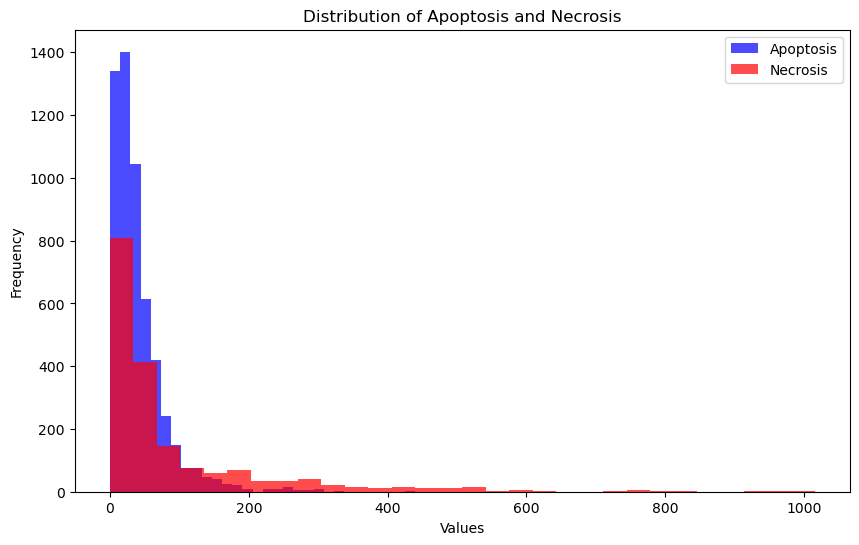

In [28]:
# Extract the data
apoptosis_data = np.concatenate(tod_pairs_3.get('necrosis'))
necrosis_data = np.concatenate(tod_pairs_2.get('necrosis'))

# Plot the histograms
plt.figure(figsize=(10, 6))
plt.hist(apoptosis_data, bins=30, alpha=0.7, label='Apoptosis', color='blue')
plt.hist(necrosis_data, bins=30, alpha=0.7, label='Necrosis', color='red')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Distribution of Apoptosis and Necrosis')
plt.legend()
plt.show()

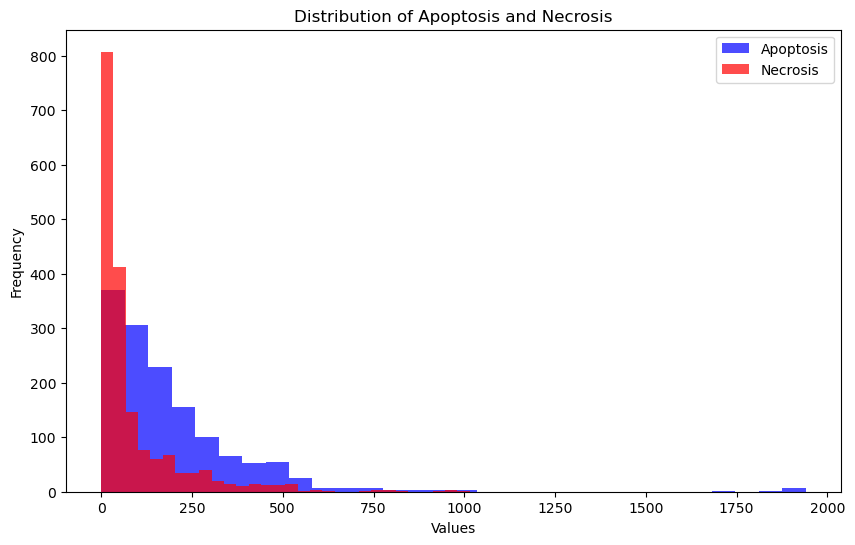

In [27]:
# Extract the data
apoptosis_data = np.concatenate(tod_pairs_2.get('apoptosis'))
necrosis_data = np.concatenate(tod_pairs_2.get('necrosis'))

# Plot the histograms
plt.figure(figsize=(10, 6))
plt.hist(apoptosis_data, bins=30, alpha=0.7, label='Apoptosis', color='blue')
plt.hist(necrosis_data, bins=30, alpha=0.7, label='Necrosis', color='red')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Distribution of Apoptosis and Necrosis')
plt.legend()
plt.show()

In [19]:
exp_names

0            field13_crop-001_ROI#1_annotation_apop.csv
1             field13_crop-001_ROI#1_annotation_nec.csv
2                 Field14-002_ROI#1_annotation_apop.csv
3                  Field14-002_ROI#1_annotation_nec.csv
4     3-19-2924_10ah2bmcherry_ROI#2_annotation_apop.csv
5      3-19-2924_10ah2bmcherry_ROI#2_annotation_nec.csv
6       7-20-23_10arednuclei_ROI#10_annotation_apop.csv
7        7-20-23_10arednuclei_ROI#10_annotation_nec.csv
8     7-20-23_10arednuclei_ROI#13_or14_both_colonies...
9     7-20-23_10arednuclei_ROI#13_or14_both_colonies...
10          field13_crop-001_ROI#1_annotation_mixed.csv
11               Field14-002_ROI#1_annotation_mixed.csv
12     7-20-23_10arednuclei_ROI#10_annotation_mixed.csv
13    7-20-23_10arednuclei_ROI#13_or14_both_colonies...
14    3-19-2924_10ah2bmcherry_ROI#2_annotation_outli...
15                          purecolony3_sytox_based.csv
16                           purecolony_sytox_based.csv
17                          purecolony2_sytox_ba